# Эксперимент 2.2
Зависимость числа итераций CG от обусловленности и размерности; сравнение с ГС (`лаб2.pdf`, п. 2.2).


In [1]:
%load_ext autoreload
%autoreload 2


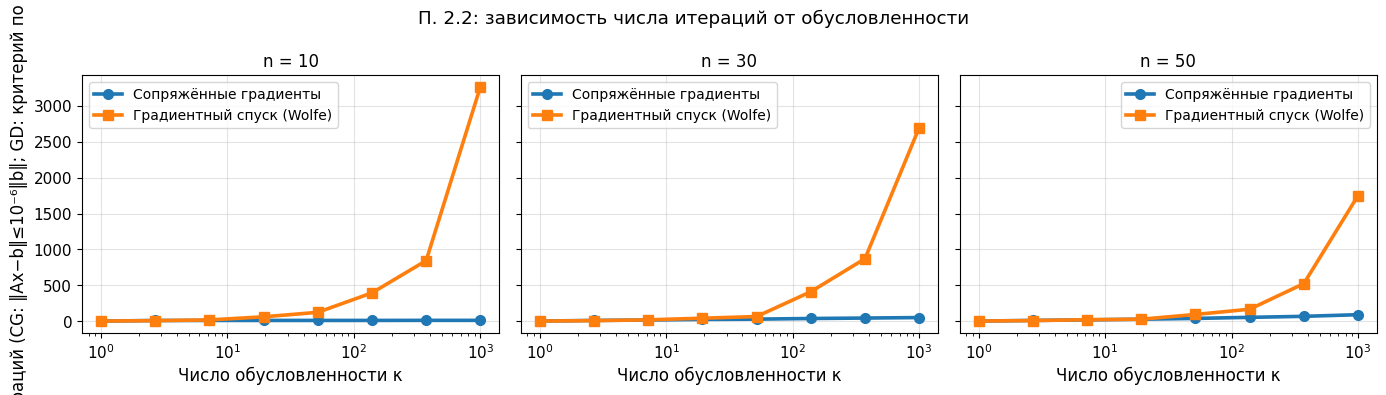

In [2]:
%matplotlib inline
import sys
import time
from pathlib import Path

_root = Path.cwd().resolve()
if _root.name == "notebooks":
    _root = _root.parent
_src = _root / "src"
if str(_src) not in sys.path:
    sys.path.insert(0, str(_src))

import matplotlib.pyplot as plt
import numpy as np
from experiments_common import (
    TimedOracle,
    init_notebook,
    load_a1a,
    load_triazines,
    make_classification_oracle,
    make_regression_oracle,
    savefig_both,
    standard_regcoef,
    train_test_oracles_regression,
)
from ml_tools import sparse_oracle_ops
from optimization import (
    gradient_descent,
    hessian_free_newton,
    lbfgs,
    newton,
    newton_modified,
    nonlinear_conjugate_gradients,
    trust_region_steihaug_newton,
)
from oracles import NonConvexOracle, QuadraticOracle, beale_mesh_Z

init_notebook()

rng = np.random.default_rng(1)
dims = [10, 30, 50]
conds = np.logspace(0, 3, 8)
fig, axes = plt.subplots(1, len(dims), figsize=(14, 4), sharey=True)


def cg_iters_count(A, b, x0, tol=1e-6):
    g = A.dot(x0) - b
    d = -g
    x = x0.copy()
    it = 0
    bn = np.linalg.norm(b)
    ref = tol * bn if bn > 0 else tol
    while it < 200 * A.shape[0]:
        it += 1
        Ad = A.dot(d)
        denom = float(d.dot(Ad))
        if abs(denom) < 1e-30:
            return it
        alpha = float(g.dot(g)) / denom
        x = x + alpha * d
        gn = A.dot(x) - b
        if np.linalg.norm(gn) <= ref:
            return it
        beta = float(gn.dot(gn)) / float(max(g.dot(g), 1e-30))
        d = -gn + beta * d
        g = gn
    return it


for ax, n in zip(axes, dims):
    it_cg, it_gd = [], []
    for kappa in conds:
        lam = np.geomspace(1.0, float(kappa), n)
        Q, _ = np.linalg.qr(rng.standard_normal((n, n)))
        A = Q @ np.diag(lam) @ Q.T
        b = rng.standard_normal(n)
        x0 = np.zeros(n)
        oracle = QuadraticOracle(A, b)
        it_cg.append(cg_iters_count(A, b, x0))
        _, _, h = gradient_descent(
            oracle,
            x0,
            tolerance=1e-6,
            max_iter=min(8000, 400 * n),
            line_search_options={"method": "Wolfe", "alpha_0": 1.0},
            trace=True,
        )
        it_gd.append(max(len(h["func"]) - 1, 0) if h else min(8000, 400 * n))
    ax.plot(conds, it_cg, "o-", label="Сопряжённые градиенты")
    ax.plot(conds, it_gd, "s-", label="Градиентный спуск (Wolfe)")
    ax.set_xscale("log")
    ax.set_xlabel("Число обусловленности κ")
    ax.set_title("n = {}".format(n))
    ax.legend()
axes[0].set_ylabel("Итераций (CG: ‖Ax−b‖≤10⁻⁶‖b‖; GD: критерий по ∇f)")
fig.suptitle("П. 2.2: зависимость числа итераций от обусловленности")
fig.tight_layout()
savefig_both(fig, "exp22_cg_vs_gd")
plt.show()
